In [ ]:
!pip install opencv-python matplotlib numpy

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [72]:
from google.colab import files
uploaded = files.upload()

Saving Screenshot 2026-04-24 221821.png to Screenshot 2026-04-24 221821.png


(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

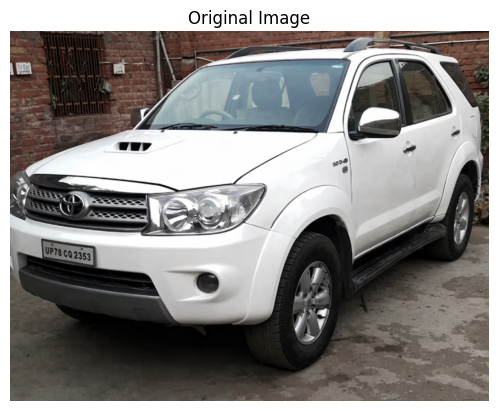

In [73]:
# Get filename
image_path = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_path)

# Convert BGR → RGB (important for display)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Show image
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')

In [74]:
def rgb_to_luminance(img):
    R = img[:,:,0]
    G = img[:,:,1]
    B = img[:,:,2]

    return 0.2126 * R + 0.7152 * G + 0.0722 * B

luminance = rgb_to_luminance(image_rgb)

(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

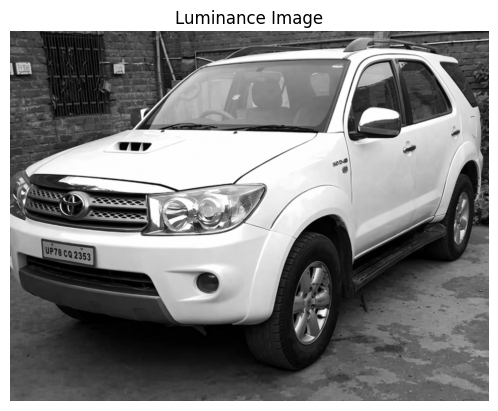

In [75]:
plt.imshow(luminance, cmap='gray')
plt.title("Luminance Image")
plt.axis('off')

In [76]:
import cv2
import numpy as np

def compute_gradients(img_gray):
    gx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)

    return magnitude, direction

In [77]:
mag, direction = compute_gradients(luminance)

(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

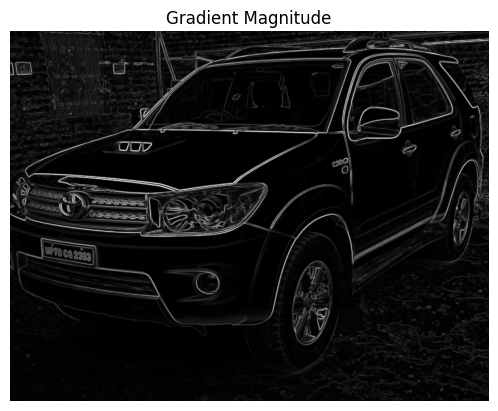

In [78]:
import matplotlib.pyplot as plt

plt.imshow(mag, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')

In [79]:
def multi_scale_gradients(img_gray):
    scales = [1, 2, 4]
    results = []

    for s in scales:
        blurred = cv2.GaussianBlur(img_gray, (0,0), sigmaX=s)
        mag, direction = compute_gradients(blurred)
        results.append((mag, direction))

    return results

In [80]:
results = multi_scale_gradients(luminance)

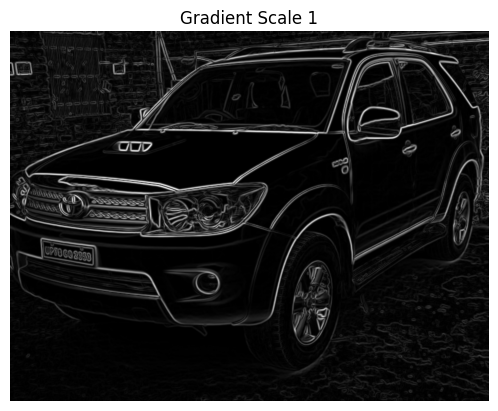

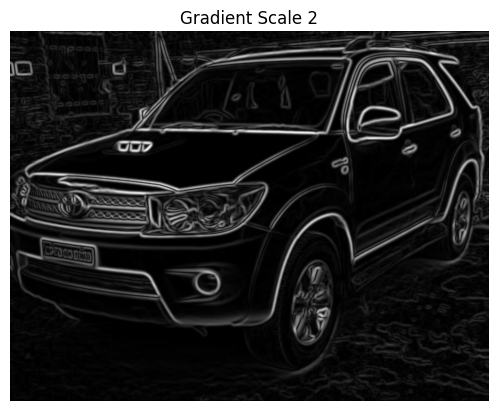

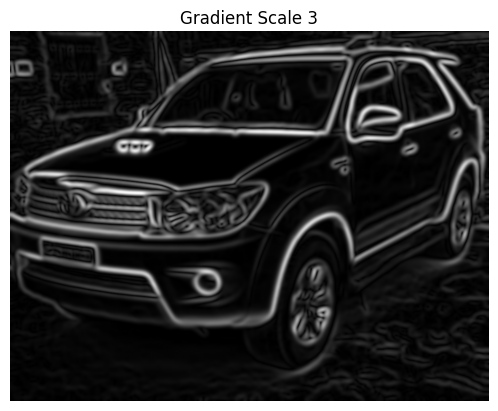

In [81]:
for i, (mag, _) in enumerate(results):
    plt.imshow(mag, cmap='gray')
    plt.title(f"Gradient Scale {i+1}")
    plt.axis('off')
    plt.show()

In [82]:
def extract_patches(feature_map, patch_size=16):
    h, w = feature_map.shape
    patches = []

    for i in range(0, h, patch_size):
        for j in range(0, w, patch_size):
            patch = feature_map[i:i+patch_size, j:j+patch_size]

            if patch.shape == (patch_size, patch_size):
                patches.append(((i, j), patch))

    return patches

In [83]:
mag1, dir1 = results[0]

patches = extract_patches(mag1)
print("Number of patches:", len(patches))

Number of patches: 2408


In [84]:
def fft_energy(patch):
    f = np.fft.fft2(patch)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    h, w = magnitude.shape
    cy, cx = h//2, w//2

    mask = np.zeros((h, w))
    mask[cy-h//4:cy+h//4, cx-w//4:cx+w//4] = 1

    high_freq = np.sum(magnitude * (1 - mask))
    low_freq = np.sum(magnitude * mask)

    return high_freq / (low_freq + 1e-6)

In [85]:
def patch_score(mag_patch, dir_patch):
    mag_std = np.std(mag_patch)
    dir_std = np.std(dir_patch)
    energy = np.sum(mag_patch**2)

    fft_feat = fft_energy(mag_patch)

    alpha = 2.0

    score = (mag_std + dir_std) * np.log(energy + 1) + alpha * fft_feat

    return score

In [86]:
mag1, dir1 = results[0]

mag_patches = extract_patches(mag1)
dir_patches = extract_patches(dir1)

scores = []

for ((i, j), mag_patch), (_, dir_patch) in zip(mag_patches, dir_patches):
    score = patch_score(mag_patch, dir_patch)
    scores.append(((i, j), score))

print("Sample scores:", scores[:5])

Sample scores: [((0, 0), np.float64(226.18434574144024)), ((0, 16), np.float64(341.91615183152226)), ((0, 32), np.float64(167.31048150912846)), ((0, 48), np.float64(485.351515044013)), ((0, 64), np.float64(558.7916198179349))]


In [87]:
patch_size = 16

h, w = mag1.shape

grid_h = h // patch_size
grid_w = w // patch_size

score_map = np.zeros((grid_h, grid_w))

for ((i, j), score) in scores:
    row = i // patch_size
    col = j // patch_size
    score_map[row, col] = score

print("Score map shape:", score_map.shape)

Score map shape: (43, 56)


In [88]:
def normalize_scores(score_map):
    h, w = score_map.shape
    norm_map = np.zeros_like(score_map)

    for i in range(h):
        for j in range(w):
            neighbors = score_map[max(i-1,0):i+2, max(j-1,0):j+2]

            local_mean = np.mean(neighbors)
            local_std = np.std(neighbors) + 1e-5

            norm_map[i,j] = (score_map[i,j] - local_mean) / local_std

    return norm_map

norm_map = normalize_scores(score_map)

In [89]:
heatmap = (norm_map - norm_map.min()) / (norm_map.max() - norm_map.min())

(np.float64(-0.5), np.float64(55.5), np.float64(42.5), np.float64(-0.5))

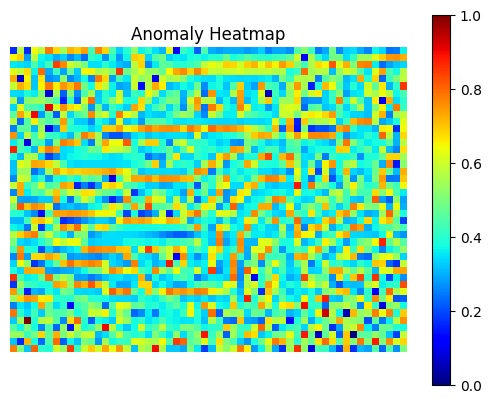

In [90]:
plt.imshow(heatmap, cmap='jet')
plt.title("Anomaly Heatmap")
plt.colorbar()
plt.axis('off')

(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

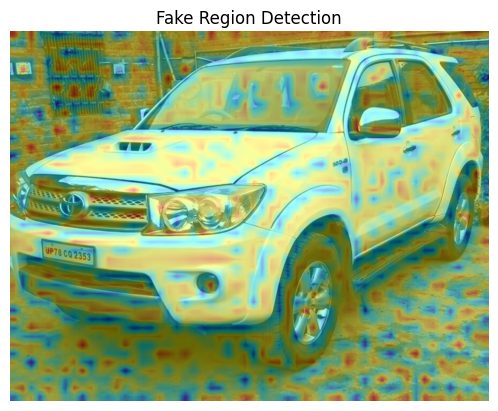

In [91]:
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(image_rgb, 0.6, heatmap_color, 0.4, 0)

plt.imshow(overlay)
plt.title("Fake Region Detection")
plt.axis('off')

In [92]:
heatmap = cv2.GaussianBlur(heatmap, (5,5), 0)

In [93]:
threshold = 0.6
#heatmap[heatmap < threshold] = 0

(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

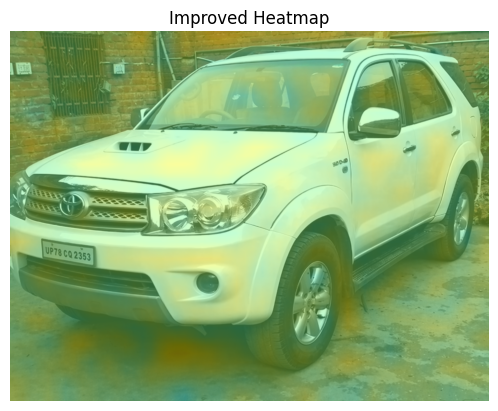

In [94]:
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(image_rgb, 0.6, heatmap_color, 0.4, 0)

plt.imshow(overlay)
plt.title("Improved Heatmap")
plt.axis('off')

In [95]:
all_scores = []

for mag, dir in results:
    mag_patches = extract_patches(mag)
    dir_patches = extract_patches(dir)

    temp_scores = []

    for ((i, j), mag_patch), (_, dir_patch) in zip(mag_patches, dir_patches):
        s = patch_score(mag_patch, dir_patch)
        temp_scores.append(s)

    all_scores.append(temp_scores)

In [96]:
final_scores = np.max(all_scores, axis=0)

In [97]:
patch_size = 16

h, w = mag1.shape

grid_h = h // patch_size
grid_w = w // patch_size

score_map = np.zeros((grid_h, grid_w))

idx = 0
for i in range(grid_h):
    for j in range(grid_w):
        score_map[i, j] = final_scores[idx]
        idx += 1

In [98]:
norm_map = normalize_scores(score_map)

In [99]:
heatmap = (norm_map - norm_map.min()) / (norm_map.max() - norm_map.min())

In [100]:
heatmap = cv2.GaussianBlur(heatmap, (5,5), 0)

threshold = 0.6
heatmap[heatmap < threshold] = 0

(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

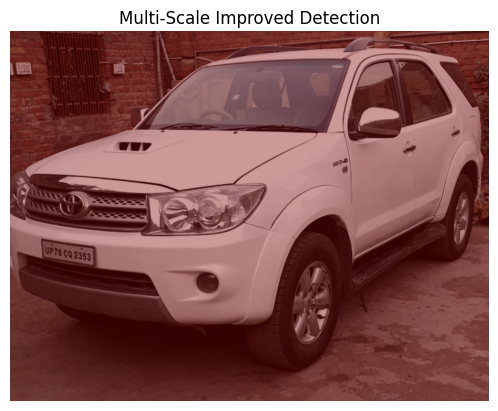

In [101]:
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))
heatmap_uint8 = np.uint8(255 * heatmap_resized)

heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(image_rgb, 0.6, heatmap_color, 0.4, 0)

plt.imshow(overlay)
plt.title("Multi-Scale Improved Detection")
plt.axis('off')

In [102]:
print("Min:", np.min(final_scores))
print("Max:", np.max(final_scores))

Min: 1.6173954664522667
Max: 3698.5978649804974


(np.float64(-0.5), np.float64(55.5), np.float64(42.5), np.float64(-0.5))

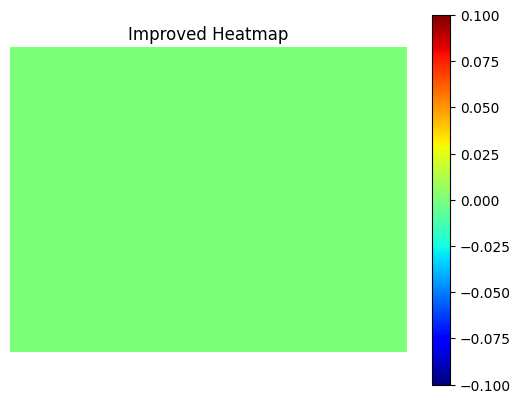

In [103]:
plt.imshow(heatmap, cmap='jet')
plt.title("Improved Heatmap")
plt.colorbar()
plt.axis('off')

In [104]:
heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)

In [105]:
heatmap = cv2.GaussianBlur(heatmap, (3,3), 0)

(np.float64(-0.5), np.float64(55.5), np.float64(42.5), np.float64(-0.5))

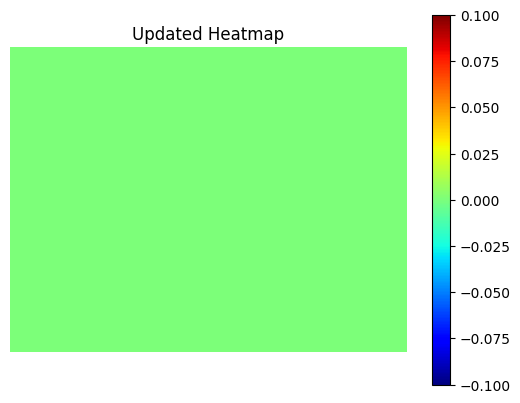

In [106]:
import matplotlib.pyplot as plt

plt.imshow(heatmap, cmap='jet')
plt.title("Updated Heatmap")
plt.colorbar()
plt.axis('off')

In [107]:
print("Final scores stats:")
print("Min:", np.min(final_scores))
print("Max:", np.max(final_scores))
print("Std:", np.std(final_scores))

Final scores stats:
Min: 1.6173954664522667
Max: 3698.5978649804974
Std: 744.6527192430331


In [108]:
heatmap = norm_map.copy()

# clip extreme values
heatmap = np.clip(heatmap, -2, 2)

# normalize
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

(np.float64(-0.5), np.float64(55.5), np.float64(42.5), np.float64(-0.5))

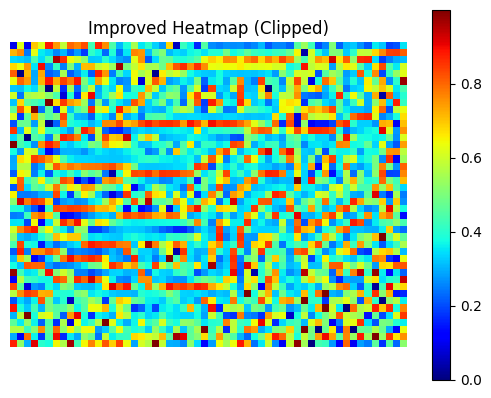

In [109]:
plt.imshow(heatmap, cmap='jet')
plt.title("Improved Heatmap (Clipped)")
plt.colorbar()
plt.axis('off')

(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

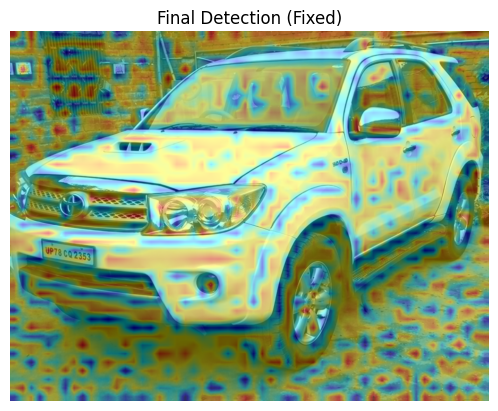

In [110]:
# Ensure same size
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))

# Convert to uint8
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Apply colormap (makes it 3-channel)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

# Ensure image is uint8
image_uint8 = np.uint8(image_rgb)

# Overlay
overlay = cv2.addWeighted(image_uint8, 0.6, heatmap_color, 0.4, 0)

# Show
plt.imshow(overlay)
plt.title("Final Detection (Fixed)")
plt.axis('off')

In [111]:
print("Average anomaly:", np.mean(norm_map))

Average anomaly: -0.048938497155916506


In [112]:
print("Mean Absolute Anomaly:", np.mean(np.abs(norm_map)))

Mean Absolute Anomaly: 0.7364632357580131


In [113]:
threshold = 1.0  # strong anomaly

high_anomaly_ratio = np.sum(norm_map > threshold) / norm_map.size

print("High anomaly ratio:", high_anomaly_ratio)

High anomaly ratio: 0.1644518272425249


In [114]:
all_scores = []

for mag, direction in results:
    mag_patches = extract_patches(mag)
    dir_patches = extract_patches(direction)

    temp = []

    for ((i,j), mp), (_, dp) in zip(mag_patches, dir_patches):
        temp.append(patch_score(mp, dp))

    all_scores.append(temp)

final_scores = np.max(all_scores, axis=0)

In [115]:
patch_size = 16
h, w = luminance.shape

grid_h = h // patch_size
grid_w = w // patch_size

score_map = np.zeros((grid_h, grid_w))

idx = 0
for i in range(grid_h):
    for j in range(grid_w):
        score_map[i,j] = final_scores[idx]
        idx += 1

(np.float64(-0.5), np.float64(55.5), np.float64(42.5), np.float64(-0.5))

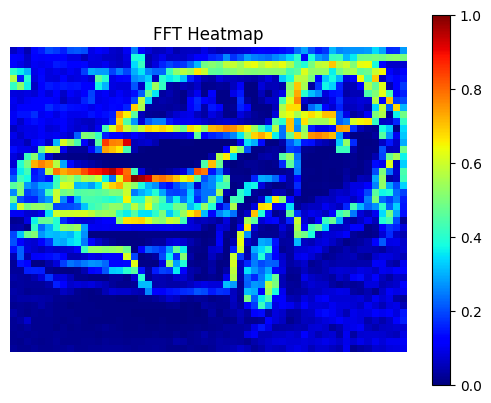

In [116]:
heatmap = score_map.copy()

heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

plt.imshow(heatmap, cmap='jet')
plt.title("FFT Heatmap")
plt.colorbar()
plt.axis('off')

Image shape: (700, 906, 3)
Heatmap shape: (700, 906, 3)


(np.float64(-0.5), np.float64(905.5), np.float64(699.5), np.float64(-0.5))

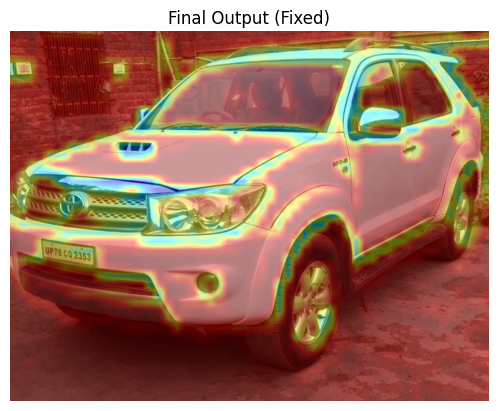

In [117]:
# 🔍 Debug shapes
print("Image shape:", image_rgb.shape)

# Resize heatmap EXACTLY to image size
heatmap_resized = cv2.resize(heatmap, (image_rgb.shape[1], image_rgb.shape[0]))

# Convert to uint8
heatmap_uint8 = np.uint8(255 * heatmap_resized)

# Apply colormap (3 channels)
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)

print("Heatmap shape:", heatmap_color.shape)

# Ensure image is uint8
image_uint8 = np.uint8(image_rgb)

# Overlay
overlay = cv2.addWeighted(image_uint8, 0.6, heatmap_color, 0.4, 0)

# Show
plt.imshow(overlay)
plt.title("Final Output (Fixed)")
plt.axis('off')

In [118]:
print("Mean:", np.mean(score_map))
print("Std:", np.std(score_map))

Mean: 648.6562189478992
Std: 744.6527192430331


In [119]:
heatmap_flat = heatmap.flatten()

print("Mean Abs:", np.mean(np.abs(heatmap_flat)))
print("High ratio:", np.sum(heatmap_flat > 0.7) / len(heatmap_flat))

Mean Abs: 0.1750181881714803
High ratio: 0.022840531561461794


In [120]:
def direction_consistency(directions):
    # Use doubled angle to handle 180° ambiguity
    cos_mean = np.mean(np.cos(2 * directions))
    sin_mean = np.mean(np.sin(2 * directions))
    coherence = np.sqrt(cos_mean**2 + sin_mean**2)
    return coherence  # 0 → random, 1 → highly aligned

In [121]:
def radial_fft_profile(patch, n_bins=8):
    f = np.abs(np.fft.fftshift(np.fft.fft2(patch)))
    h, w = f.shape
    cy, cx = h//2, w//2

    y, x = np.ogrid[-cy:h-cy, -cx:w-cx]
    r = np.sqrt(x*x + y*y)
    r_max = r.max()

    bins = []
    for i in range(n_bins):
        r1 = i * r_max / n_bins
        r2 = (i+1) * r_max / n_bins
        mask = (r >= r1) & (r < r2)
        bins.append(np.mean(f[mask]))

    return np.array(bins)

def fft_flatness(profile):
    # flatter profile = more suspicious
    return np.std(profile) / (np.mean(profile) + 1e-6)

In [122]:
def patch_score(mag_patch, dir_patch):
    # 1) Direction structure
    coherence = direction_consistency(dir_patch)

    # 2) FFT structure
    profile = radial_fft_profile(mag_patch)
    flatness = fft_flatness(profile)

    # Final score:
    # low coherence (random directions) → suspicious
    # high flatness (uniform frequency) → suspicious
    score = (1 - coherence) + 2.0 * flatness

    return score

In [123]:
flat = heatmap.flatten()

print("Mean Abs:", np.mean(np.abs(flat)))
print("High ratio:", np.sum(flat > 0.7) / len(flat))

Mean Abs: 0.1750181881714803
High ratio: 0.022840531561461794


In [124]:
# collect coherence values
coherence_values = []

for mag, direction in results:
    dir_patches = extract_patches(direction)
    for (_, dp) in dir_patches:
        coherence_values.append(direction_consistency(dp))

print("Avg coherence:", np.mean(coherence_values))

Avg coherence: 0.5653657236336695


In [1]:
!pip install scikit-learn

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [10]:
!pip install datasets

In [11]:
from datasets import load_dataset

dataset = load_dataset("cifar10")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/120M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/23.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [12]:
real_images = []

for i in range(50):  # take 50 samples
    img = dataset['train'][i]['img']
    img = np.array(img)
    img = cv2.resize(img, (256,256))
    real_images.append(img)

print("Real images:", len(real_images))

Real images: 50


In [13]:
ai_images = []

for img in real_images:
    noisy = img + np.random.normal(0, 25, img.shape)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    ai_images.append(noisy)

print("AI images:", len(ai_images))

AI images: 50


In [15]:
def extract_features(image_rgb):
    luminance = 0.2126*image_rgb[:,:,0] + 0.7152*image_rgb[:,:,1] + 0.0722*image_rgb[:,:,2]

    results = multi_scale_gradients(luminance)

    features = []

    for mag, direction in results:
        mag_patches = extract_patches(mag)
        dir_patches = extract_patches(direction)

        for (_, mp), (_, dp) in zip(mag_patches, dir_patches):
            mag_std = np.std(mp)
            dir_std = np.std(dp)
            coherence = direction_consistency(dp)
            fft_feat = fft_energy(mp)

            features.append([mag_std, dir_std, coherence, fft_feat])

    # Convert to array
    features = np.array(features)

    # Take mean across patches (simple approach)
    return np.mean(features, axis=0)